In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def get_video_capture():
    video_path = Path("../Material_TPs/TP2/focus_video.mov")
    return cv.VideoCapture(video_path)

## Video Original

In [3]:
captura_video = get_video_capture()

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    # Obtén la tasa de cuadros (frame rate) del video
    fps = int(captura_video.get(cv.CAP_PROP_FPS))
    # fps = 35
    delay = int(600 / fps)
    
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break

        # Mostrar el frame combinado
        cv.imshow('Video Original y Blur Gaussiano', frame)
        
        # Salir del loop si se presiona la tecla 'q'
        if cv.waitKey(delay) & 0xFF == ord('q'):
            break

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/cimimuxmaio/projects/posgrados/inteligencia-artificial/tps_vpc_1/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/cimimuxmaio/projects/posgrados/inteligencia-artificial/tps_vpc_1/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/cimimuxmaio/projects/posgrados/inteligencia-artificial/tps_vpc_1/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/cimimuxmaio/projects/posgrados/inteligencia-artificial/tps_vpc_1/.venv/lib/python3.12/site-pac

## Definicion del Algoritmo

In [4]:
def center_region(image, ratio):
    h, w = image.shape[:2]
    
    # Escala según porcentaje
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    
    # Coordenadas del centro
    cx, cy = w // 2, h // 2
    
    # Límites del recorte
    x1 = cx - new_w // 2
    x2 = cx + new_w // 2
    y1 = cy - new_h // 2
    y2 = cy + new_h // 2
    
    # Recorte
    cropped = image[y1:y2, x1:x2]
    return cropped

def image_quality_measure(image):
    # Convertir a escala de grises
    image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    w, h = image.shape
    f = np.fft.fft2(image)
    fc = np.fft.fftshift(f)
    af = np.abs(fc)
    m = np.max(af)
    threshold = m / 1000 
    t_h = (af > threshold).sum()
    return t_h / (w * h)

## Medicion por frame completo de video

In [6]:
captura_video = get_video_capture()

ROI_SIZE = 0.1

frame_scores = []
roi_scores = []

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break

        # Tomo una subregion central del frame
        roi = center_region(frame, ROI_SIZE)

        frame_scores.append(image_quality_measure(frame))
        roi_scores.append(image_quality_measure(roi))

# Libera el objeto de captura de video y cierra todas las ventanas
captura_video.release()
cv.destroyAllWindows()

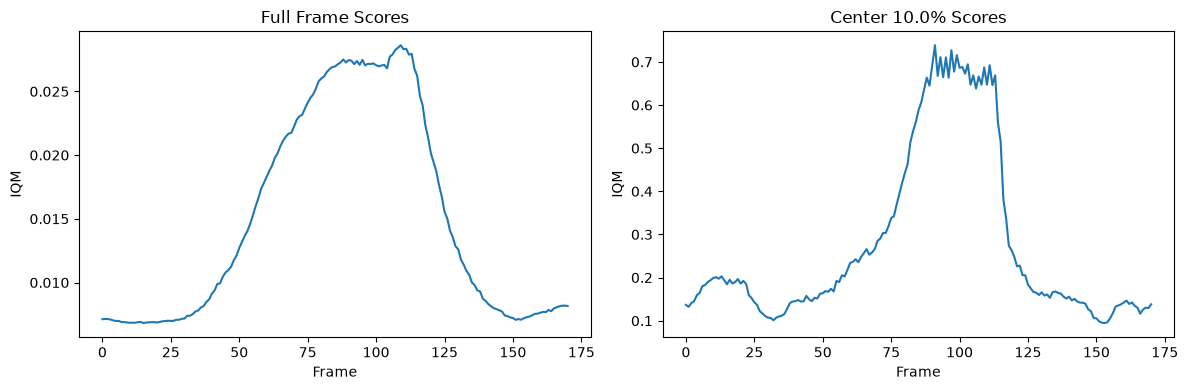

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(frame_scores)
axs[0].set_title("Full Frame Scores")
axs[0].set_xlabel("Frame")
axs[0].set_ylabel("IQM")

axs[1].plot(roi_scores)
axs[1].set_title(f"Center {ROI_SIZE * 100}% Scores")
axs[1].set_xlabel("Frame")
axs[1].set_ylabel("IQM")

plt.tight_layout()
plt.show()

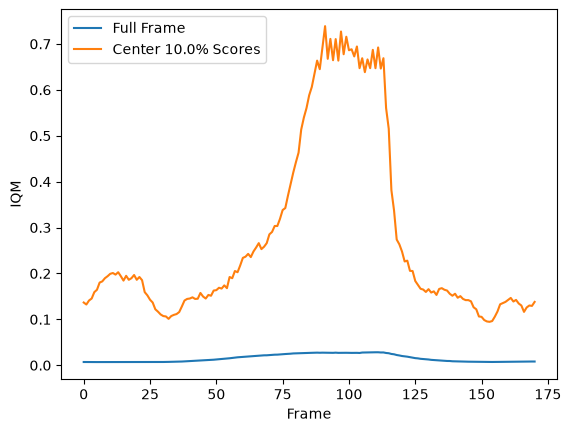

In [8]:
plt.plot(frame_scores, label="Full Frame")
plt.plot(roi_scores, label=f"Center {ROI_SIZE * 100}% Scores")
plt.xlabel("Frame")
plt.ylabel("IQM")
plt.legend()
plt.show()